# Run-centric graph-state transition visualization

This notebook analyzes **one hallucinated response at a time and one hallucination span at a time**. It fixes the main confounds in the earlier rich t-SNE workflow: generator provenance is explicit, position effects are residualized against same-generator correct controls, correlated hand-crafted features are block-balanced, cumulative history-lag bins are made disjoint, and each error onset is compared with a matched correct-control transition null.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from transition_visualization import TransitionSampleVisualizer

DATA_ROOT = Path('/share/home/tm902089733300000/a903202310/lys/data/RAGTruth/model_traces/llama31_8b/test')
OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'single_sample_transition'

# RAGTruth does not contain Llama-3.1-8B-generated responses. Leave None to use
# the generator recorded in the canonical manifest, or set e.g. 'llama-2-7b-chat'.
GENERATOR_MODEL = None
ERROR_SAMPLE_ID = '10071'
ERROR_INDEX = 0
PRE_WINDOW = 10
POST_WINDOW = 10
LOCAL_RADIUS = 18
MAX_CONTROLS = 32


In [2]:
viewer = TransitionSampleVisualizer(
    DATA_ROOT,
    output_root=OUTPUT_ROOT,
    generator_model=GENERATOR_MODEL,
    random_state=0,
)
provenance = viewer.provenance()
provenance


{'split_root': '/share/home/tm902089733300000/a903202310/lys/data/RAGTruth/model_traces/llama31_8b/test',
 'observer_model': 'Meta-Llama-3.1-8B-Instruct',
 'manifest_generator_model': 'llama-2-7b-chat',
 'available_generator_models': ['llama-2-7b-chat'],
 'selected_generator_model': 'llama-2-7b-chat',
 'same_generator_and_observer': False,
 'selected_samples': 449,
 'selected_hallucinated_samples': 226,
 'selected_correct_samples': 223}

## Verify model provenance

`observer_model` is the model whose internal attention is being analyzed. `selected_generator_model` is the model that originally wrote the RAGTruth response text. If they differ, this is a teacher-forced/proxy analysis rather than a same-generator internal-state experiment.


In [3]:
sample_id = (
    str(ERROR_SAMPLE_ID)
    if ERROR_SAMPLE_ID is not None
    else viewer.error_sample_ids[ERROR_INDEX]
)
sample = viewer.dataset[sample_id]
print('sample_id:', sample_id)
print('observer_model:', sample.observer_model)
print('generator_model:', sample.generator_model)
print('task_type:', sample.task_type, 'data_source:', sample.data_source)
print('positive_runs:', viewer.labels.positive_runs(sample_id))
viewer.runs(sample_id, pre_window=PRE_WINDOW, post_window=POST_WINDOW)


sample_id: 10071
observer_model: Meta-Llama-3.1-8B-Instruct
generator_model: llama-2-7b-chat
task_type: Data2txt data_source: Yelp
positive_runs: [[81, 84], [85, 87]]


[RunWindow(run_index=0, error_start=81, error_end=84, clean_pre_start=71, clean_pre_end=81, clean_post_start=84, clean_post_end=85),
 RunWindow(run_index=1, error_start=85, error_end=87, clean_pre_start=84, clean_pre_end=85, clean_post_start=87, clean_post_end=97)]

## Run-centric analysis

Each hallucination span is handled independently. For nearby spans such as sample 10071, the second run may have only a very short clean pre-error segment; the metadata records this instead of silently mixing the previous hallucination into `pre_error`.


{'sample_id': '10071',
 'provenance': {'split_root': '/share/home/tm902089733300000/a903202310/lys/data/RAGTruth/model_traces/llama31_8b/test',
  'observer_model': 'Meta-Llama-3.1-8B-Instruct',
  'manifest_generator_model': 'llama-2-7b-chat',
  'available_generator_models': ['llama-2-7b-chat'],
  'selected_generator_model': 'llama-2-7b-chat',
  'same_generator_and_observer': False,
  'selected_samples': 449,
  'selected_hallucinated_samples': 226,
  'selected_correct_samples': 223},
 'positive_runs': [[81, 84], [85, 87]],
 'run_windows': [{'run_index': 0,
   'error': [81, 84],
   'clean_pre': [71, 81],
   'clean_post': [84, 85],
   'pre_length': 10,
   'error_length': 3,
   'post_length': 1},
  {'run_index': 1,
   'error': [85, 87],
   'clean_pre': [84, 85],
   'clean_post': [87, 97],
   'pre_length': 1,
   'error_length': 2,
   'post_length': 10}],
 'same_generator_control_ids': ['6771',
  '7323',
  '6981',
  '8559',
  '10335',
  '8217',
  '8661',
  '9213'],
 'metrics': [{'sample_id':

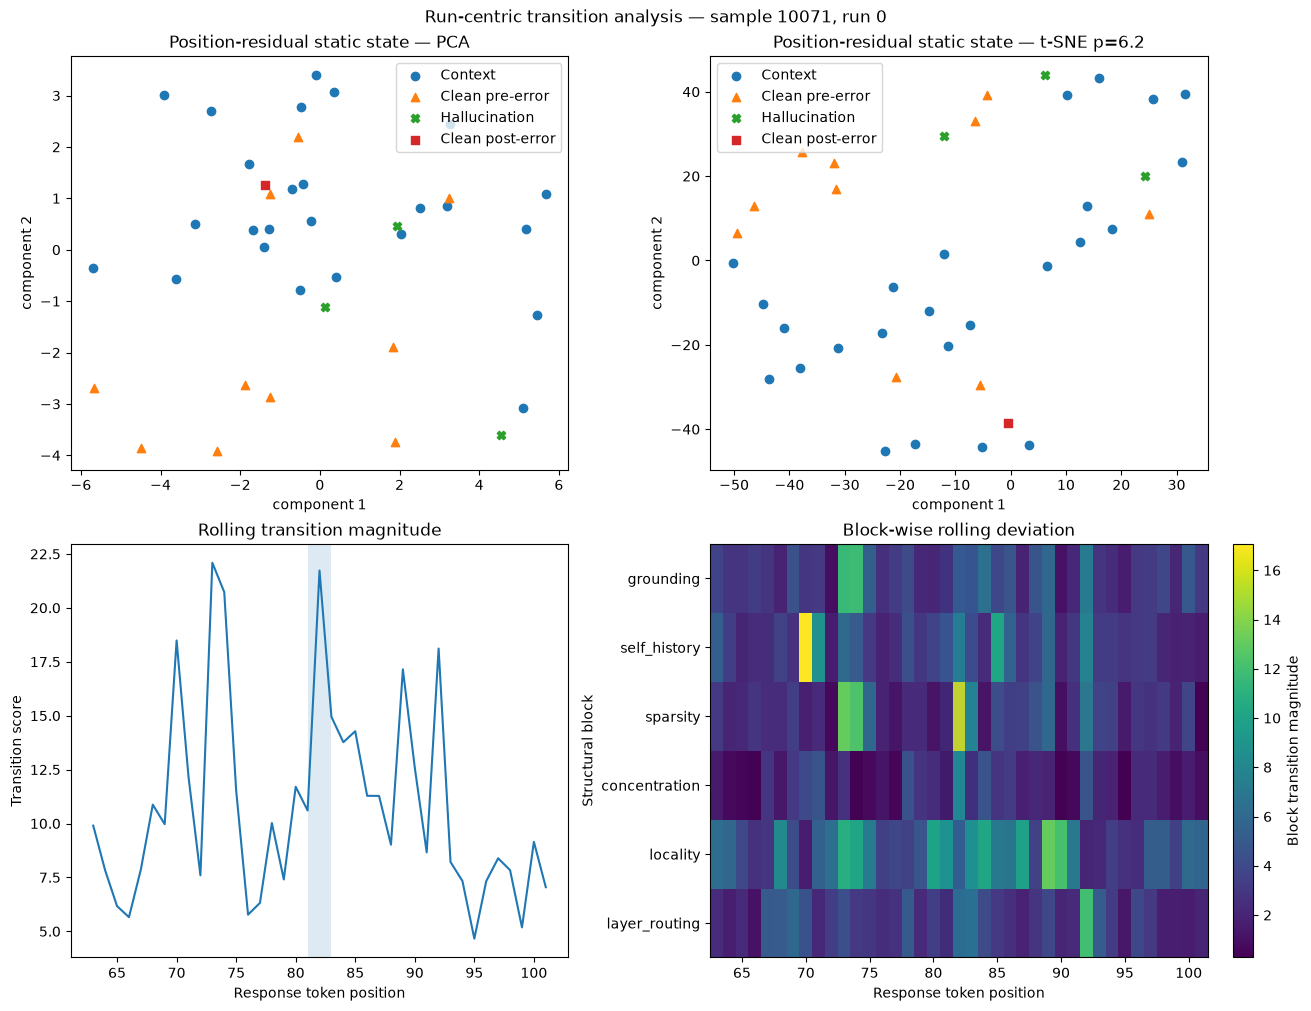

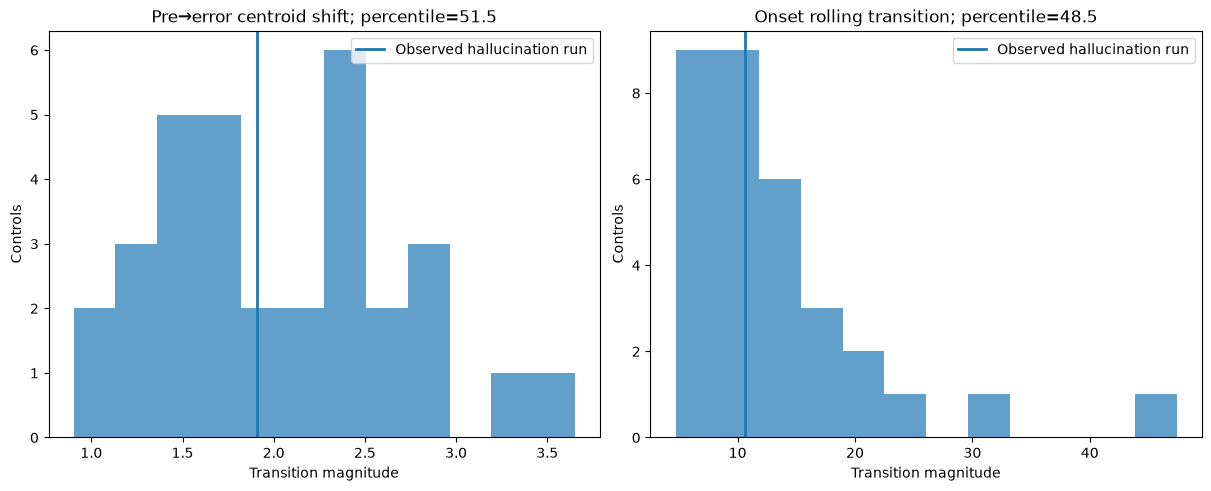

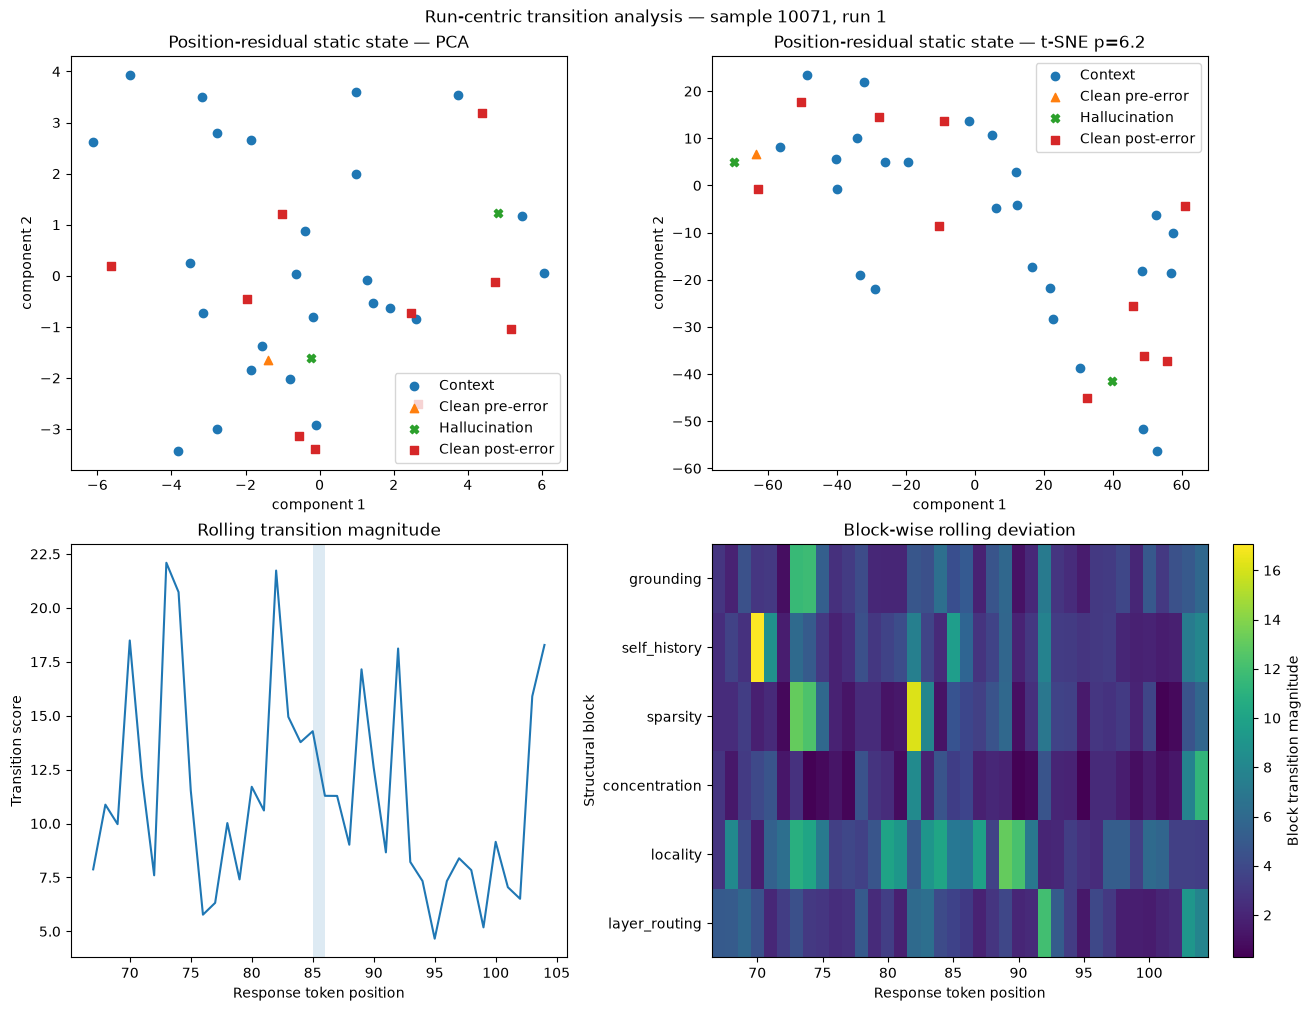

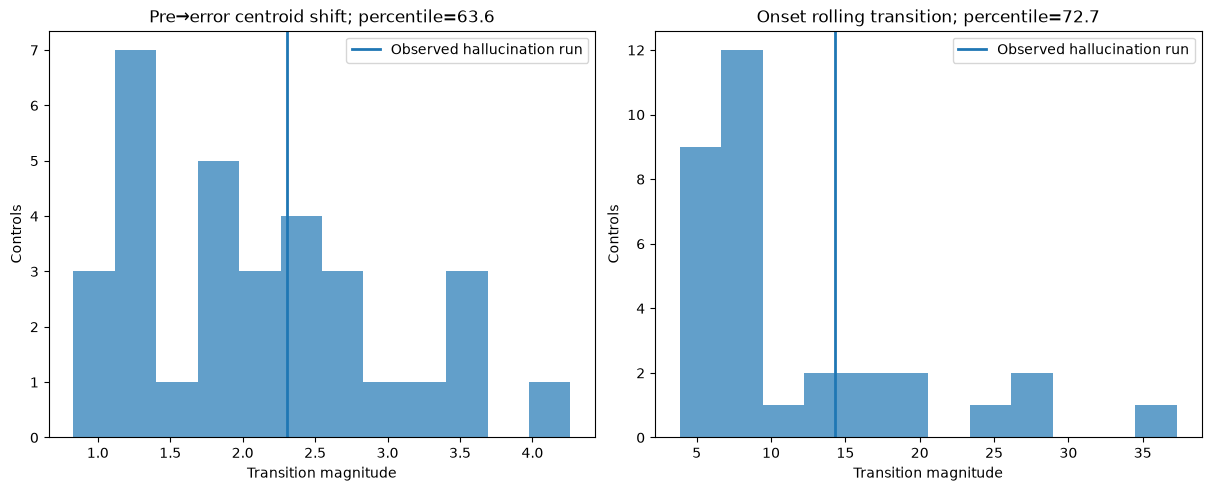

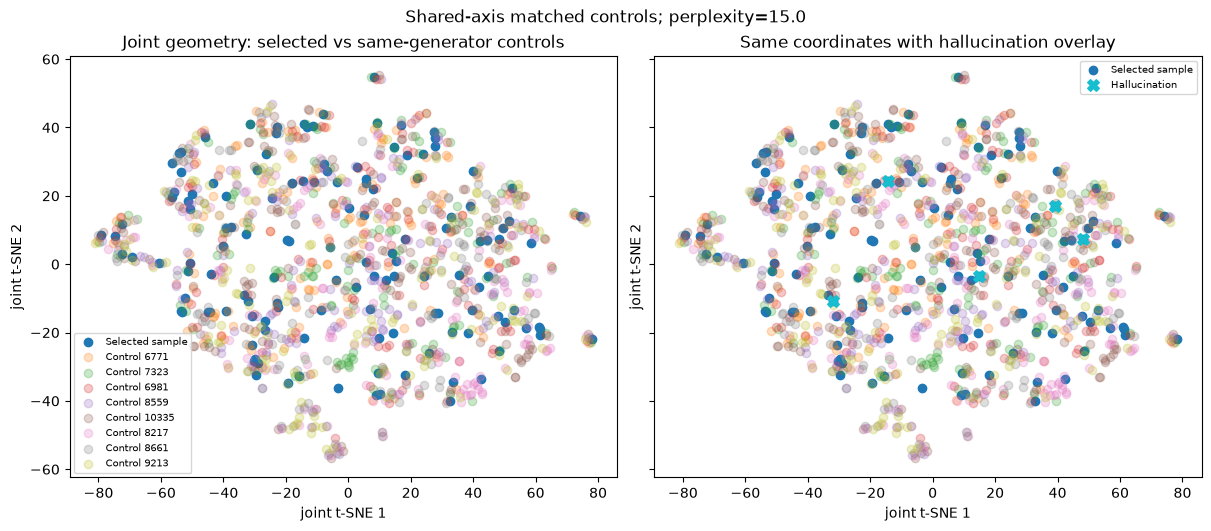

In [4]:
result = viewer.visualize(
    sample_id,
    pre_window=PRE_WINDOW,
    post_window=POST_WINDOW,
    local_radius=LOCAL_RADIUS,
    max_controls=MAX_CONTROLS,
)
result['metadata']


## Inspect one run numerically

The empirical percentiles compare the observed pre→error state shift and onset transition score against pseudo-onsets at matched normalized positions in fully correct responses from the **same generator**.


In [5]:
RUN_INDEX = 0
viewer.run_metrics(
    sample_id,
    run_index=RUN_INDEX,
    pre_window=PRE_WINDOW,
    post_window=POST_WINDOW,
    max_controls=MAX_CONTROLS,
)


{'sample_id': '10071',
 'run': {'run_index': 0,
  'error': [81, 84],
  'clean_pre': [71, 81],
  'clean_post': [84, 85],
  'pre_length': 10,
  'error_length': 3,
  'post_length': 1},
 'generator_model': 'llama-2-7b-chat',
 'observer_model': 'Meta-Llama-3.1-8B-Instruct',
 'control_count': 32,
 'clean_pre_sufficient': True,
 'observed_centroid_shift': 1.9103947877883911,
 'centroid_shift_null': [1.3407952785491943,
  2.280398368835449,
  1.438271164894104,
  1.7632012367248535,
  1.779619812965393,
  1.9320532083511353,
  2.9300053119659424,
  2.7951488494873047,
  2.4460411071777344,
  1.3211990594863892,
  2.3199150562286377,
  1.2215510606765747,
  1.716079831123352,
  2.552213191986084,
  1.5268338918685913,
  0.9542003870010376,
  3.6509647369384766,
  2.1468992233276367,
  2.3432350158691406,
  1.5979020595550537,
  1.8165135383605957,
  1.4862102270126343,
  2.5317845344543457,
  0.9031715989112854,
  1.8961209058761597,
  2.2520930767059326,
  1.3932753801345825,
  2.4683339595794